#### Student name: Thandiwe Feziwe Mangana
#### Student ID: 24325104

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install polars
!pip install fg-data-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.3/400.3 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 90.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.5 MB/s eta 0:00:00


In [ ]:
import polars as pl
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, RobustScaler, FunctionTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_recall_fscore_support
from sklearn import set_config
import pickle
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.stats import loguniform, randint, uniform
from sklearn.feature_selection import RFE, SelectFromModel
from sklearn.ensemble import ExtraTreesClassifier
pd.set_option('display.max_columns', None)
from pathlib import Path
from data_profiling import ProfileReport
import seaborn as sns
from sklearn.impute import SimpleImputer

###Data loading and sampling

In [ ]:
# @title
class FeatureTaxanomy:
    """
    Contains features' schema

    """

    FEATURE_MAP = {
    'length_to':'length_to_address',
    'is_contract_creation':'coming_from_contract',
    'length_from':'length_from_address',
    'is_same_address':'from_is_same_as_to_address',
    'duration_seconds':'duration',
    'gas_used.gas_used_summation':'gas_used_summation',
    'gas_used.gas_used_average':'gas_used_average',
    'gas_used.gas_used_median':'gas_used_median',
    'gas_used.gas_used_standard_deviation':'gas_used_standard_deviation',
    'gas_used.gas_used_maximum_val':'gas_used_maximum_val',
    'gas_used.gas_used_minimum_val':'gas_used_minimum_val',
    'gas_used.gas_used_variance':'gas_used_variance',
    'gas_used.gas_used_range_value':'gas_used_range_value',
    'gas_used.gas_used_skewness':'gas_used_skewness',
    'gas_used.gas_used_mode':'gas_used_mode',
    'gas_used.gas_used_coefficient_of_variation':'gas_used_coefficient_of_variation',
    'gas_prices.gas_prices_summation':'gas_prices_summation',
    'gas_prices.gas_prices_average':'gas_prices_average',
    'gas_prices.gas_prices_median':'gas_prices_median',
    'gas_prices.gas_prices_standard_deviation':'gas_prices_standard_deviation',
    'gas_prices.gas_prices_maximum_val':'gas_prices_maximum_val',
    'gas_prices.gas_prices_minimum_val':'gas_prices_minimum_val',
    'gas_prices.gas_prices_variance':'gas_prices_variance',
    'gas_prices.gas_prices_range_value':'gas_prices_range_value',
    'gas_prices.gas_prices_skewness':'gas_prices_skewness',
    'gas_prices.gas_prices_mode':'gas_prices_mode',
    'gas_prices.gas_prices_coefficient_of_variation':'gas_prices_coefficient_of_variation',
    'cumulativeGasUsed.cumulativeGasUsed_summation':'cumulativeGasUsed_summation',
    'cumulativeGasUsed.cumulativeGasUsed_average':'cumulativeGasUsed_average',
    'cumulativeGasUsed.cumulativeGasUsed_median':'cumulativeGasUsed_median',
    'cumulativeGasUsed.cumulativeGasUsed_standard_deviation':'cumulativeGasUsed_standard_deviation',
    'cumulativeGasUsed.cumulativeGasUsed_maximum_val':'cumulativeGasUsed_maximum_val',
    'cumulativeGasUsed.cumulativeGasUsed_minimum_val':'cumulativeGasUsed_minimum_val',
    'cumulativeGasUsed.cumulativeGasUsed_variance':'cumulativeGasUsed_variance',
    'cumulativeGasUsed.cumulativeGasUsed_range_value':'cumulativeGasUsed_range_value',
    'cumulativeGasUsed.cumulativeGasUsed_skewness':'cumulativeGasUsed_skewness',
    'cumulativeGasUsed.cumulativeGasUsed_mode':'cumulativeGasUsed_mode',
    'cumulativeGasUsed.cumulativeGasUsed_coefficient_of_variation':'cumulativeGasUsed_coefficient_of_variation',
    'values.values_summation':'values_summation',
    'values.values_average':'values_average',
    'values.values_median':'values_median',
    'values.values_standard_deviation':'values_standard_deviation',
    'values.values_maximum_val':'values_maximum_val',
    'values.values_minimum_val':'values_minimum_val',
    'values.values_variance':'values_variance',
    'values.values_range_value':'values_range_value',
    'values.values_skewness':'values_skewness',
    'values.values_mode':'values_mode',
    'values.values_coefficient_of_variation':'values_coefficient_of_variation',
    'nonce.nonce_summation':'nonce_summation',
    'nonce.nonce_average':'nonce_average',
    'nonce.nonce_median':'nonce_median',
    'nonce.nonce_standard_deviation':'nonce_standard_deviation',
    'nonce.nonce_maximum_val':'nonce_maximum_val',
    'nonce.nonce_minimum_val':'nonce_minimum_val',
    'nonce.nonce_variance':'nonce_variance',
    'nonce.nonce_range_value':'nonce_range_value',
    'nonce.nonce_skewness':'nonce_skewness',
    'nonce.nonce_mode':'nonce_mode',
    'nonce.nonce_coefficient_of_variation':'nonce_coefficient_of_variation'}

    FEATURE_TO_KEEP = [
    'length_transaction_hash',
    'length_to_address',
    'coming_from_contract',
    'status',
    'log_removed',
    'block_number',
    'gas_used',
    'length_from_address',
    'index',
    'gas_efficiency',
    'value',
    'chain_id',
    'message',
    'total_gas_cost',
    'gas_per_log_event',
    'log_index',
    'event_activity_flag',
    'normalized_token_transfer',
    'effective_gas_price',
    'cumulative_gas_used',
    'from_is_same_as_to_address',
    'gas_price_ratio',
    'token_transfer_amount',
    'length_log',
    'Error!',
    'log_count',
    'num_transaction',
    'duration',
    'number_of_errors',
    'error_rate',
    'gas_used_summation',
    'gas_used_average',
    'gas_used_median',
    'gas_used_standard_deviation',
    'gas_used_maximum_val',
    'gas_used_minimum_val',
    'gas_used_variance',
    'gas_used_range_value',
    'gas_used_skewness',
    'gas_used_mode',
    'gas_used_coefficient_of_variation',
    'gas_prices_summation',
    'gas_prices_average',
    'gas_prices_median',
    'gas_prices_standard_deviation',
    'gas_prices_maximum_val',
    'gas_prices_minimum_val',
    'gas_prices_variance',
    'gas_prices_range_value',
    'gas_prices_skewness',
    'gas_prices_mode',
    'gas_prices_coefficient_of_variation',
    'cumulativeGasUsed_summation',
    'cumulativeGasUsed_average',
    'cumulativeGasUsed_median',
    'cumulativeGasUsed_standard_deviation',
    'cumulativeGasUsed_maximum_val',
    'cumulativeGasUsed_minimum_val',
    'cumulativeGasUsed_variance',
    'cumulativeGasUsed_range_value',
    'cumulativeGasUsed_skewness',
    'cumulativeGasUsed_mode',
    'cumulativeGasUsed_coefficient_of_variation',
    'values_summation',
    'values_average',
    'values_median',
    'values_standard_deviation',
    'values_maximum_val',
    'values_minimum_val',
    'values_variance',
    'values_range_value',
    'values_skewness',
    'values_mode',
    'values_coefficient_of_variation',
    'nonce_summation',
    'nonce_average',
    'nonce_median',
    'nonce_standard_deviation',
    'nonce_maximum_val',
    'nonce_minimum_val',
    'nonce_variance',
    'nonce_range_value',
    'nonce_skewness',
    'nonce_mode',
    'nonce_coefficient_of_variation',
    'number_of_from_address',
    'number_of_unique_from_address',
    'number_of_to_address',
    'number_of_unique_to_address'
    ]

In [ ]:
# @title

class DataIngestion:
    """
    Contains functions for matrix manipulation namely:
    a : multiplication
    b : transpose
    c : inverse

    """

    base_path = ''
    fraud_path = ''
    legitimate_path = ''
    fraud_parquet_path = ''
    legitimate_parquet_path = ''

    def __init__(self, base_path, fraud_filename, legitimate_filename):

        """
        Constructor for the DataIngester class.
        It takes the parameters and generates file paths.

        Parameters
        ----------
        base_path : string
            The path to the folder in which all the data is stored.
        fraud_filename : string
            The name of the file containing the fraud data.
        legitimate_filename : string
            The name of the file containing the legitimate data.

        """
        self.base_path = base_path
        self.fraud_path = self.base_path + fraud_filename
        self.legitimate_path = self.base_path + legitimate_filename

        fraud_parquet_filename = 'fraud.parquet'
        self.fraud_parquet_path = self.base_path + fraud_parquet_filename
        legitimate_parquet_filename = 'legitimate.parquet'
        self.legitimate_parquet_path = self.base_path + legitimate_parquet_filename

    def ingest_data(self):

        """
        Ingests the raw data from the csv files and saves it as parquet files.

        This is to optimise for large csv files

        Parameters
        ----------
        None

        Returns
        -------
        tuple
            The paths to the generated and saved parquet files.

        """
        q_fraud = pl.scan_csv(self.fraud_path,
                       infer_schema_length=10000,
                       ignore_errors=True,
                       schema_overrides={'token_transfer_amount':pl.Float64})

        q_fraud.sink_parquet(self.fraud_parquet_path)

        q_legitimate = pl.scan_csv(self.legitimate_path,
                       infer_schema_length=10000,
                       ignore_errors=True,
                       schema_overrides={'token_transfer_amount':pl.Float64})

        q_legitimate.sink_parquet(self.legitimate_parquet_path)

        return self.fraud_parquet_path, self.legitimate_parquet_path

    def extract_subset(self, fraud_parquet_path, legitimate_parquet_path, n_samples=20000):

        """
        Extracts a subset of the data from the parquet files.
        It combines the fraud and legitimate data and saves it as a parquet file.

        Parameters
        ----------
        n_samples : int
            The number of samples to extract from each dataset.
            The default is 20000.
        fraud_parquet_path : string
            The path to the parquet file containing the fraud data.
        legitimate_parquet_path : string
            The path to the parquet file containing the legitimate data.

        Returns
        -------
        string
            The path to the generated and saved parquet file.

        """

        lazy_legitimate = pl.scan_parquet(legitimate_parquet_path)
        lazy_fraud = pl.scan_parquet(fraud_parquet_path)

        #Creating one dataset and extracting a sample of 20 000
        legitimate_count = lazy_legitimate.select(pl.len()).collect().item()
        fraud_count = lazy_fraud.select(pl.len()).collect().item()

        print(f"Normal transactions: {legitimate_count}")
        print(f"Fraud transactions: {fraud_count}")

        #Calculating the target for 20k rows
        total_sample = 20000
        fraud_ratio = fraud_count / (legitimate_count + fraud_count)
        target_fraud = int(total_sample * fraud_ratio)
        target_legitimate = total_sample - target_fraud

        #List of columns that have a mismatch
        mismatch_cols = ['erc_721_TokenAddress', 'erc_721_TokenName', 'erc_721_TokenSymbol']

        #Standardize both LazyFrames to String
        lazy_fraud = lazy_fraud.with_columns([
            pl.col(c).cast(pl.String) for c in mismatch_cols
        ])

        lazy_legitimate = lazy_legitimate.with_columns([
            pl.col(c).cast(pl.String) for c in mismatch_cols
        ])

        #Sampling from LazyFrames
        df_fraud = lazy_fraud.collect().sample(n=target_fraud, shuffle=True, seed=42)
        df_legitimate = lazy_legitimate.collect().sample(n=target_legitimate, shuffle=True, seed=42)

        #Concatenating and shuffling
        df_final = pl.concat([df_fraud, df_legitimate]).sample(fraction=1.0, shuffle=True, seed=42)

        #Save as parquet
        df_final.write_parquet(self.base_path + 'dataset.parquet')

        #Save as csv
        df_final.write_csv(self.base_path + 'dataset.csv')
        return self.base_path + 'dataset.parquet'

    def get_processed_data(self, dataset_parquet_path):

        """
        Loads the dataset from the parquet file and splits it into training and testing sets.
        It also renames the columns to more align with the feature taxonomy.

        Parameters
        ----------
        string: dataset_parquet_path
            The path to the parquet file containing the dataset.

        Returns
        -------
        tuple
            The X_train, X_test, y_train, y_test.

        """

        df = pd.read_parquet(dataset_parquet_path)
        y = df['flag']
        X = df.drop(columns=['flag'], axis=1)

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y)

        X_train = X_train.rename(columns=FeatureTaxanomy.FEATURE_MAP)
        X_test = X_test.rename(columns=FeatureTaxanomy.FEATURE_MAP)

        X_train = X_train[FeatureTaxanomy.FEATURE_TO_KEEP]
        X_test = X_test[FeatureTaxanomy.FEATURE_TO_KEEP]

        return X_train, X_test, y_train, y_test


In [ ]:
legitimate_parquet_path = "" #= '/content/drive/MyDrive/thesis_data/DeFiTransLyzer_legitimate.parquet'
fraud_parquet_path  = "" #= "/content/drive/MyDrive/thesis_data/DeFiTransLyzer_fraud.parquet"
dataset_path = '/content/drive/MyDrive/thesis_data/dataset.parquet'

data_ingestion = DataIngestion('/content/drive/MyDrive/thesis_data/', 'DeFiTransLyzer_fraud.csv', 'DeFiTransLyzer_legitimate.csv')
#fraud_parquet_path, legitimate_parquet_path = data_ingestion.ingest_data()
#dataset_path = data_ingestion.extract_subset(fraud_parquet_path, legitimate_parquet_path)
X_train, X_test, y_train, y_test = data_ingestion.get_processed_data(dataset_path)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test type: {type(y_test)}")
print(f"y_train type: {type(y_train)}")

X_train shape: (16000, 89)
X_test shape: (4000, 89)
y_test type: <class 'pandas.core.series.Series'>
y_train type: <class 'pandas.core.series.Series'>


###Exploratory data analysis (EDA) and data preparation

In [ ]:

class DataPreparation:

    SKEWED_FEATURES = ['values_minimum_val','total_gas_cost','gas_used_minimum_val','value','nonce_minimum_val','values_variance']
    CATEGORICAL_FEATURES = ['event_activity_flag','chain_id','from_is_same_as_to_address']
    STANDARD_FEATURES =  ['length_transaction_hash','coming_from_contract','status','log_removed','block_number','gas_used', 'length_from_address','index','gas_efficiency', 'message','gas_per_log_event','log_index','normalized_token_transfer','effective_gas_price','cumulative_gas_used','gas_price_ratio',
        'token_transfer_amount','length_log','Error!','log_count','num_transaction','duration','number_of_errors','error_rate','gas_used_summation','gas_used_average','gas_used_median','gas_used_standard_deviation','gas_used_maximum_val','gas_used_variance','gas_used_range_value',
        'gas_used_skewness', 'gas_used_mode','gas_used_coefficient_of_variation','gas_prices_summation', 'gas_prices_average', 'gas_prices_median','gas_prices_standard_deviation','gas_prices_maximum_val','gas_prices_minimum_val','gas_prices_variance', 'gas_prices_range_value',
        'gas_prices_skewness','gas_prices_mode','gas_prices_coefficient_of_variation', 'cumulativeGasUsed_summation','cumulativeGasUsed_average','cumulativeGasUsed_median','cumulativeGasUsed_standard_deviation', 'cumulativeGasUsed_maximum_val', 'cumulativeGasUsed_minimum_val', 'cumulativeGasUsed_variance',
        'cumulativeGasUsed_range_value', 'cumulativeGasUsed_skewness','cumulativeGasUsed_mode','cumulativeGasUsed_coefficient_of_variation', 'values_summation', 'values_average','values_median', 'values_standard_deviation','values_maximum_val','values_range_value',
        'values_skewness','values_mode','values_coefficient_of_variation','nonce_summation','nonce_average','nonce_median', 'nonce_standard_deviation','nonce_maximum_val','nonce_variance','nonce_range_value', 'nonce_skewness','nonce_mode', 'nonce_coefficient_of_variation',
        'number_of_from_address','number_of_unique_from_address','number_of_to_address','number_of_unique_to_address' ]
    BINARIZE_FEATURES = ['length_to_address']


    @property
    def skewed_features(self):
      return list( set(FeatureTaxanomy.FEATURE_TO_KEEP).intersection(self.SKEWED_FEATURES))

    @property
    def standard_features(self):
      return list( set(FeatureTaxanomy.FEATURE_TO_KEEP).intersection(self.STANDARD_FEATURES))

    @property
    def categorical_features(self):
      return list( set(FeatureTaxanomy.FEATURE_TO_KEEP).intersection(self.CATEGORICAL_FEATURES))

    @property
    def binarize_features(self):
      return list( set(FeatureTaxanomy.FEATURE_TO_KEEP).intersection(self.BINARIZE_FEATURES))

    def update_features(self, features_to_drop):
      FeatureTaxanomy.FEATURE_TO_KEEP = list(set(FeatureTaxanomy.FEATURE_TO_KEEP) - set(features_to_drop))

    def plot_feature_by_fraud_flag(self, X_train, y_train, feature):
      #Check distribution of a feature by fraud status
      plt.figure(figsize=(10, 6))
      sns.boxplot(x=y_train, y=X_train[feature])
      plt.title(f'Distribution of {feature} by outcome')
      plt.show()

    def generate_profiling_report(self, X_train, report_path):
      profile_data = X_train.drop(columns=['df_index'], errors='ignore')
      profile = ProfileReport(profile_data, title="Thesis Dataset Profiling: Training Set",
                            correlations={
            "pearson": {"calculate": True},
            "spearman": {"calculate": False},
            "kendall": {"calculate": False},
            "phi_k": {"calculate": False},
        },
        interactions={"continuous": False})
      #Save the report as an HTML file
      profile.to_file(report_path)

    def generate_preprocessing_pipeline(self):

        clean_inf = FunctionTransformer(
            lambda X: np.where(np.isinf(X), np.nan, X),
            feature_names_out="one-to-one")

        enforce_finite = FunctionTransformer(
            lambda X: np.clip(np.nan_to_num(X, posinf=1e18, neginf=-1e18), -1e18, 1e18),
            feature_names_out="one-to-one")


        skew_pipeline = Pipeline(steps=[
        ('clean_inf', clean_inf),
        ('enforce_finite', enforce_finite),
        ('imputer', SimpleImputer(strategy='median')),
        ('log', FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ('scale', RobustScaler())])

        standard_pipeline = Pipeline(steps=[
        ('clean_inf', clean_inf),
        ('enforce_finite', enforce_finite),
        ('imputer', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())])

        binarize_cat = FunctionTransformer(
            lambda X: (X == 0).astype(int),
            feature_names_out="one-to-one")

        binary_pipe = Pipeline(steps=[
            ('binarize', binarize_cat)])

        flag_pipeline = Pipeline(steps=[
        ('passthrough', FunctionTransformer(lambda X: X))])

        preprocess_pipeline = ColumnTransformer(
        transformers=[
            ('skew', skew_pipeline, self.skewed_features),
            ('standard', standard_pipeline, self.standard_features),
            ('binary', binary_pipe, self.binarize_features),
            ('flags', flag_pipeline, self.categorical_features)
        ],
        remainder="drop",
        verbose_feature_names_out=False)

        preprocess_pipeline.set_output(transform="pandas")
        return preprocess_pipeline


In [ ]:
X_train.head(5)

,gas_used_skewness,gas_prices_mode,duration,values_mode,error_rate,nonce_median,number_of_to_address,cumulativeGasUsed_variance,cumulativeGasUsed_maximum_val,cumulativeGasUsed_minimum_val,event_activity_flag,gas_used_minimum_val,gas_used_variance,values_skewness,gas_prices_median,gas_used_standard_deviation,gas_used_range_value,gas_prices_range_value,cumulativeGasUsed_skewness,cumulativeGasUsed_mode,values_variance,nonce_coefficient_of_variation,values_median,total_gas_cost,value,cumulativeGasUsed_standard_deviation,gas_used_coefficient_of_variation,nonce_average,number_of_errors,values_range_value,gas_prices_minimum_val,chain_id,gas_prices_summation,nonce_standard_deviation,gas_prices_variance,cumulativeGasUsed_average,block_number,number_of_unique_from_address,gas_prices_maximum_val,gas_prices_coefficient_of_variation,num_transaction,length_to_address,nonce_mode,gas_efficiency,cumulative_gas_used,nonce_variance,cumulativeGasUsed_median,values_average,number_of_from_address,values_standard_deviation,values_coefficient_of_variation,from_is_same_as_to_address,gas_used_summation,gas_used_mode,gas_prices_standard_deviation,gas_used,cumulativeGasUsed_summation,values_minimum_val,nonce_skewness,effective_gas_price,values_maximum_val,nonce_summation,gas_prices_skewness,nonce_maximum_val,gas_used_maximum_val,cumulativeGasUsed_range_value,cumulativeGasUsed_coefficient_of_variation,index,gas_used_average,gas_prices_average,token_transfer_amount,values_summation,nonce_minimum_val,nonce_range_value,gas_used_median,number_of_unique_to_address
4881,50.516798,4.200000e+14,58484.0,9.950000e+17,0.00,4993.5,10000.0,1.779220e+11,4519599.0,21000.0,0,21000.0,1.722723e+06,62.929985,4.200000e+14,1312.525266,94039.0,1.880780e+15,3.745714,21000.0,9.610000e+43,0.578129,4.200000e+19,4.200000e+14,2.624600e+19,4.218078e+05,0.062346,4.993503e+03,0.0,8.000000e+23,4.200000e+14,0,4.250000e+18,2.886890e+03,1.420000e+27,2.866067e+05,2058782,3.0,2.300780e+15,0.088682,10000.0,42,0.0,3.000000,63000,8.334136e+06,147000.0,6.800000e+20,10000.0,9.800000e+21,14.420616,0,210521888.0,21000.0,3.767690e+13,21000,2.866067e+09,5.000000e+15,0.000006,2.000000e+10,8.000000e+23,4.993503e+07,22.330009,9993.0,115039.0,4498599.0,1.471730,2,21052.18880,4.248550e+14,0.0,6.800000e+24,0.0,9993.0,21000.0,5031.0
9245,0.535455,4.200000e+14,19413.0,1.020000e+18,0.00,26938.0,5983.0,1.866340e+12,11976908.0,21000.0,1,21000.0,1.976807e+07,20.463910,6.083200e+14,4446.130317,9416.0,5.638080e+15,2.456755,21000.0,9.120000e+36,2.170914,1.920000e+18,7.662410e+14,5.886520e+18,1.366139e+06,0.182016,1.374285e+06,0.0,1.160000e+20,5.670000e+12,1,3.810000e+18,2.983454e+06,1.100000e+29,9.782071e+05,3014090,11.0,5.643750e+15,0.522241,5983.0,42,0.0,10.000000,304160,8.901000e+12,408278.0,2.340000e+18,5983.0,3.020000e+18,1.292690,0,146147794.0,21000.0,3.323790e+14,30416,5.852613e+09,1.022750e+14,5.129674,2.519203e+10,1.160000e+20,8.222346e+09,2.558190,29746820.0,30416.0,11955908.0,1.396574,9,24427.17600,6.364480e+14,0.0,1.400000e+22,0.0,29746820.0,21000.0,5.0
3722,0.000000,8.610000e+14,50207.0,5.000000e+17,0.00,4.5,28.0,7.411390e+12,7942371.0,100110.0,0,21000.0,0.000000e+00,1.530715,8.610000e+14,0.000000,0.0,2.037000e+15,0.959598,417756.0,9.210000e+36,2.437922,8.070000e+17,8.610000e+14,1.949530e+18,2.722386e+06,0.000000,5.340165e+05,0.0,1.090000e+19,6.300000e+13,1,2.660000e+16,1.301891e+06,3.740000e+29,2.491630e+06,5984283,19.0,2.100000e+15,0.644488,28.0,42,0.0,68.330286,1434936,1.694920e+12,970900.0,2.360000e+18,28.0,3.030000e+18,1.287046,0,588000.0,21000.0,6.115060e+14,21000,6.976565e+07,1.997300e+15,3.275492,4.100000e+10,1.090000e+19,1.495246e+07,0.172597,6162349.0,21000.0,7842261.0,1.092612,51,21000.00000,9.488250e+14,0.0,6.600000e+19,0.0,6162349.0,21000.0,3.0
15825,47.247899,1.040610e+15,25043.0,0.000000e+00,2.01,67.0,10000.0,3.525500e+12,7996369.0,30000.0,1,17800.0,8.896095e+09,65.016708,1.036950e+15,94319.110840,6371450.0,1.470000e+17,1.239632,70553.0,1.550000e+30,2.562018,0.000000e+00,1.040610e+15,0.0

In [ ]:
data_preparation = DataPreparation()
#data_preparation.generate_profiling_report(X_train, '/content/drive/MyDrive/thesis_data/data_profiling_report.html')

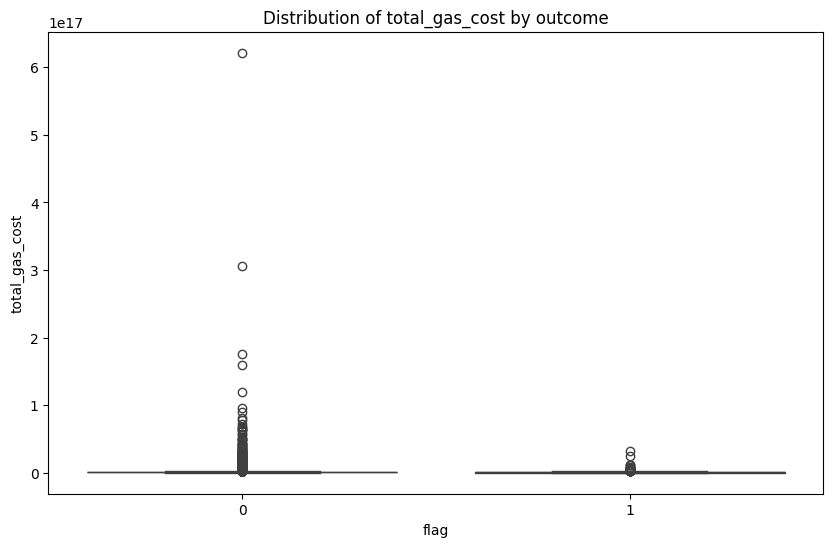

In [ ]:
data_preparation.plot_feature_by_fraud_flag(X_train, y_train, 'total_gas_cost')

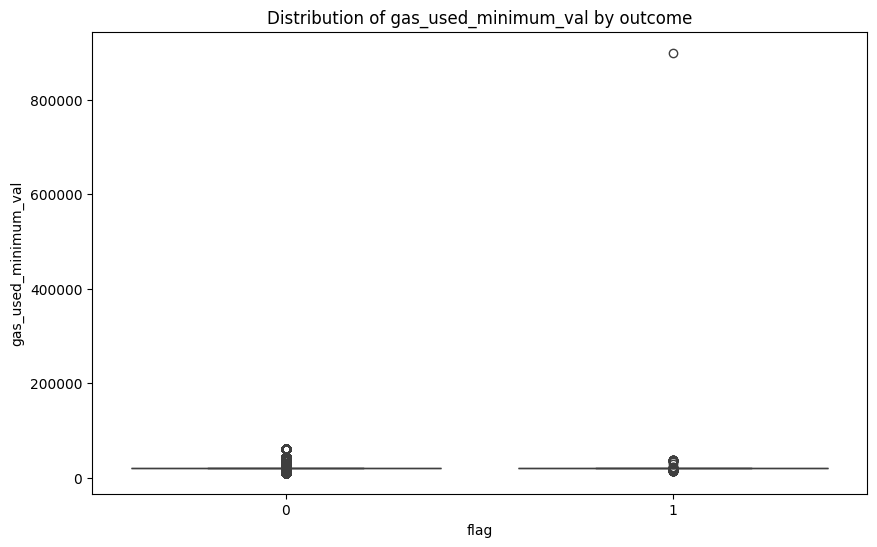

In [ ]:
data_preparation.plot_feature_by_fraud_flag(X_train, y_train, 'gas_used_minimum_val')

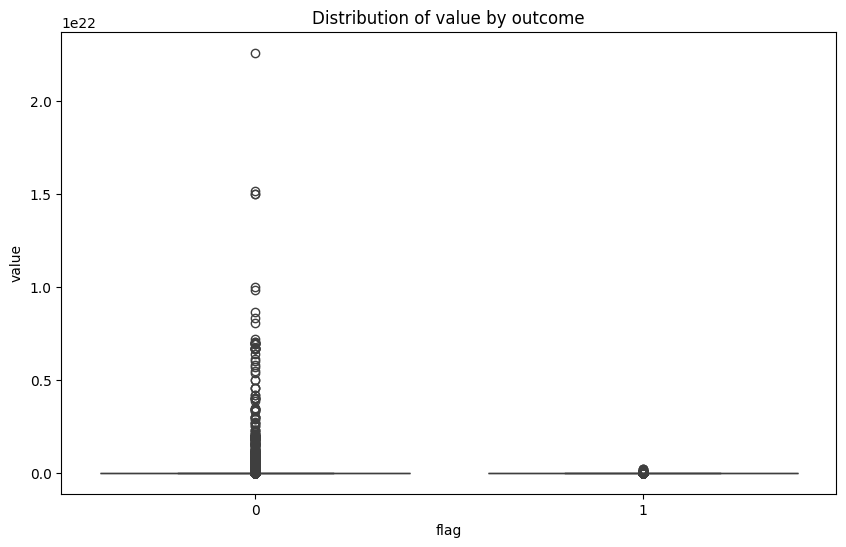

In [ ]:
data_preparation.plot_feature_by_fraud_flag(X_train, y_train,'value')

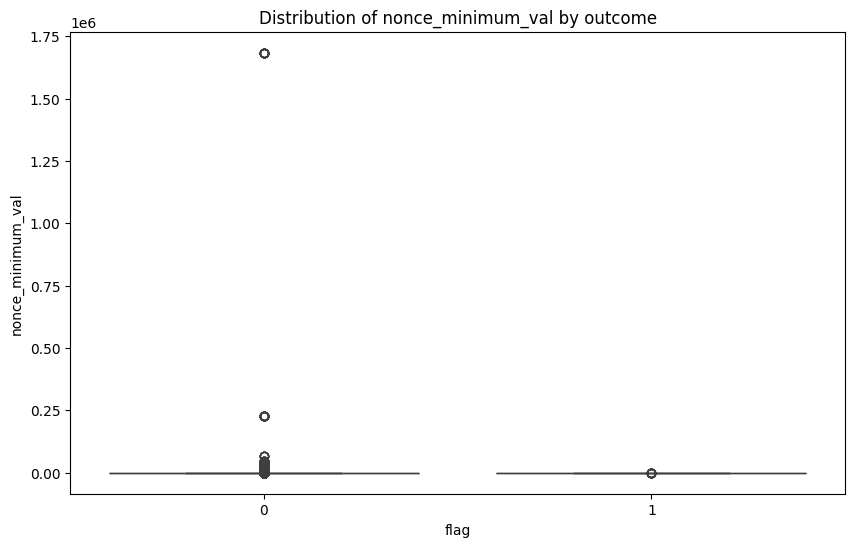

In [ ]:
data_preparation.plot_feature_by_fraud_flag(X_train, y_train,'nonce_minimum_val')

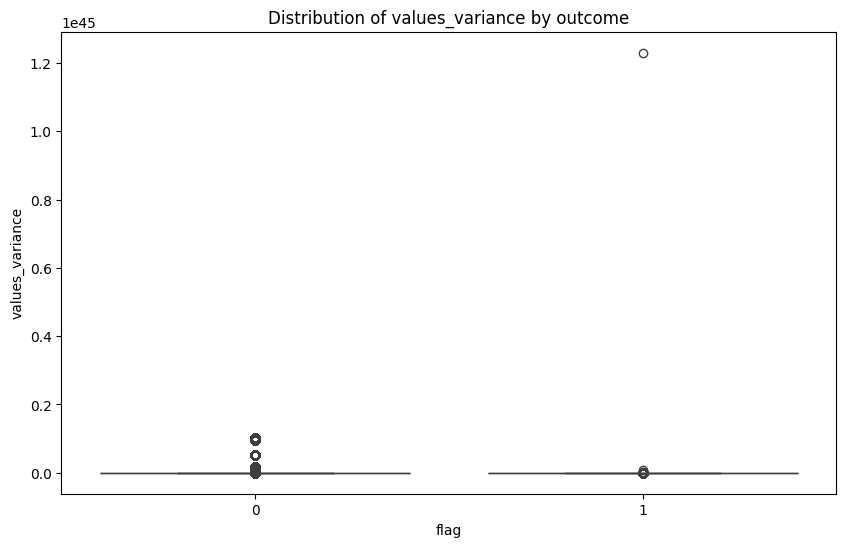

In [ ]:
data_preparation.plot_feature_by_fraud_flag(X_train, y_train,'values_variance')

In [ ]:
num_X = X_train.select_dtypes(include=[np.number])

inf_cols = num_X.columns[np.isinf(num_X).any()]
inf_cols.tolist()

['token_transfer_amount']

In [ ]:
X_train['token_transfer_amount'].describe()

,token_transfer_amount
count,16000.0
mean,inf
std,NaN
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,inf


In [ ]:
X_train['length_to_address'].describe()

,length_to_address
count,16000.000000
mean,41.485500
std,4.620132
min,0.000000
25%,42.000000
50%,42.000000
75%,42.000000
max,42.000000


In [ ]:
features_to_drop = ['message', 'status', 'coming_from_contract', 'Error!', 'gas_price_ratio', 'gas_per_log_event','log_count', 'log_removed', 'log_index', 'length_log', 'normalized_token_transfer','length_from_address','length_transaction_hash']

data_preparation.update_features(features_to_drop)

X_train, X_test, y_train, y_test = data_ingestion.get_processed_data(dataset_path)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
X_train.head(5)

X_train shape: (16000, 76)
X_test shape: (4000, 76)


,gas_used_skewness,gas_prices_mode,duration,values_mode,error_rate,nonce_median,number_of_to_address,cumulativeGasUsed_variance,cumulativeGasUsed_maximum_val,cumulativeGasUsed_minimum_val,event_activity_flag,gas_used_minimum_val,gas_used_variance,values_skewness,gas_prices_median,gas_used_standard_deviation,gas_used_range_value,gas_prices_range_value,cumulativeGasUsed_skewness,cumulativeGasUsed_mode,values_variance,nonce_coefficient_of_variation,values_median,total_gas_cost,value,cumulativeGasUsed_standard_deviation,gas_used_coefficient_of_variation,nonce_average,number_of_errors,values_range_value,gas_prices_minimum_val,chain_id,gas_prices_summation,nonce_standard_deviation,gas_prices_variance,cumulativeGasUsed_average,block_number,number_of_unique_from_address,gas_prices_maximum_val,gas_prices_coefficient_of_variation,num_transaction,length_to_address,nonce_mode,gas_efficiency,cumulative_gas_used,nonce_variance,cumulativeGasUsed_median,values_average,number_of_from_address,values_standard_deviation,values_coefficient_of_variation,from_is_same_as_to_address,gas_used_summation,gas_used_mode,gas_prices_standard_deviation,gas_used,cumulativeGasUsed_summation,values_minimum_val,nonce_skewness,effective_gas_price,values_maximum_val,nonce_summation,gas_prices_skewness,nonce_maximum_val,gas_used_maximum_val,cumulativeGasUsed_range_value,cumulativeGasUsed_coefficient_of_variation,index,gas_used_average,gas_prices_average,token_transfer_amount,values_summation,nonce_minimum_val,nonce_range_value,gas_used_median,number_of_unique_to_address
4881,50.516798,4.200000e+14,58484.0,9.950000e+17,0.00,4993.5,10000.0,1.779220e+11,4519599.0,21000.0,0,21000.0,1.722723e+06,62.929985,4.200000e+14,1312.525266,94039.0,1.880780e+15,3.745714,21000.0,9.610000e+43,0.578129,4.200000e+19,4.200000e+14,2.624600e+19,4.218078e+05,0.062346,4.993503e+03,0.0,8.000000e+23,4.200000e+14,0,4.250000e+18,2.886890e+03,1.420000e+27,2.866067e+05,2058782,3.0,2.300780e+15,0.088682,10000.0,42,0.0,3.000000,63000,8.334136e+06,147000.0,6.800000e+20,10000.0,9.800000e+21,14.420616,0,210521888.0,21000.0,3.767690e+13,21000,2.866067e+09,5.000000e+15,0.000006,2.000000e+10,8.000000e+23,4.993503e+07,22.330009,9993.0,115039.0,4498599.0,1.471730,2,21052.18880,4.248550e+14,0.0,6.800000e+24,0.0,9993.0,21000.0,5031.0
9245,0.535455,4.200000e+14,19413.0,1.020000e+18,0.00,26938.0,5983.0,1.866340e+12,11976908.0,21000.0,1,21000.0,1.976807e+07,20.463910,6.083200e+14,4446.130317,9416.0,5.638080e+15,2.456755,21000.0,9.120000e+36,2.170914,1.920000e+18,7.662410e+14,5.886520e+18,1.366139e+06,0.182016,1.374285e+06,0.0,1.160000e+20,5.670000e+12,1,3.810000e+18,2.983454e+06,1.100000e+29,9.782071e+05,3014090,11.0,5.643750e+15,0.522241,5983.0,42,0.0,10.000000,304160,8.901000e+12,408278.0,2.340000e+18,5983.0,3.020000e+18,1.292690,0,146147794.0,21000.0,3.323790e+14,30416,5.852613e+09,1.022750e+14,5.129674,2.519203e+10,1.160000e+20,8.222346e+09,2.558190,29746820.0,30416.0,11955908.0,1.396574,9,24427.17600,6.364480e+14,0.0,1.400000e+22,0.0,29746820.0,21000.0,5.0
3722,0.000000,8.610000e+14,50207.0,5.000000e+17,0.00,4.5,28.0,7.411390e+12,7942371.0,100110.0,0,21000.0,0.000000e+00,1.530715,8.610000e+14,0.000000,0.0,2.037000e+15,0.959598,417756.0,9.210000e+36,2.437922,8.070000e+17,8.610000e+14,1.949530e+18,2.722386e+06,0.000000,5.340165e+05,0.0,1.090000e+19,6.300000e+13,1,2.660000e+16,1.301891e+06,3.740000e+29,2.491630e+06,5984283,19.0,2.100000e+15,0.644488,28.0,42,0.0,68.330286,1434936,1.694920e+12,970900.0,2.360000e+18,28.0,3.030000e+18,1.287046,0,588000.0,21000.0,6.115060e+14,21000,6.976565e+07,1.997300e+15,3.275492,4.100000e+10,1.090000e+19,1.495246e+07,0.172597,6162349.0,21000.0,7842261.0,1.092612,51,21000.00000,9.488250e+14,0.0,6.600000e+19,0.0,6162349.0,21000.0,3.0
15825,47.247899,1.040610e+15,25043.0,0.000000e+00,2.01,67.0,10000.0,3.525500e+12,7996369.0,30000.0,1,17800.0,8.896095e+09,65.016708,1.036950e+15,94319.110840,6371450.0,1.470000e+17,1.239632,70553.0,1.550000e+30,2.562018,0.000000e+00,1.040610e+15,0.0

In [ ]:
#data_preparation.generate_profiling_report(X_train, '/content/drive/MyDrive/thesis_data/data_profiling_report_processesed.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


 91%|█████████ | 69/76 [00:01<00:00, 55.64it/s]/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1344: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean

100%|██████████| 76/76 [00:01<00:00, 49.55it/s]
/usr/local/lib/python3.12/dist-packages/data_profiling/model/correlations.py:87: UserWarning: There was an attempt to calculate the auto correlation, but this failed.
To hide this warning, disable the calculation
(using `df.profile_report(correlations={"auto": {"calculate": False}})`
If this is problematic for your use case, please report this as an issue:
https://github.com/Data-Centric-AI-Community/data-profiling/issues
(include the error messa

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Report generated! Check your file browser in Colab to download it.


In [ ]:
pipe_test = data_preparation.generate_preprocessing_pipeline()
result = pipe_test.fit_transform(X_train)

In [ ]:
result['length_to_address'].describe()

,length_to_address
count,16000.000000
mean,0.012250
std,0.110003
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [ ]:
result['length_to_address'].value_counts()

,count
length_to_address,
0,15804
1,196


In [ ]:
result

,total_gas_cost,value,values_minimum_val,nonce_minimum_val,values_variance,gas_used_minimum_val,gas_used_skewness,gas_prices_mode,block_number,duration,number_of_unique_from_address,values_mode,error_rate,nonce_median,gas_prices_maximum_val,gas_prices_coefficient_of_variation,num_transaction,number_of_to_address,cumulativeGasUsed_variance,nonce_mode,cumulativeGasUsed_maximum_val,cumulativeGasUsed_minimum_val,gas_used_variance,gas_efficiency,values_skewness,cumulative_gas_used,gas_prices_median,cumulativeGasUsed_median,values_average,gas_used_standard_deviation,gas_used_range_value,nonce_variance,values_standard_deviation,gas_prices_range_value,number_of_from_address,cumulativeGasUsed_skewness,values_coefficient_of_variation,cumulativeGasUsed_mode,values_median,nonce_coefficient_of_variation,gas_used_summation,gas_used_mode,gas_prices_standard_deviation,cumulativeGasUsed_standard_deviation,gas_used_coefficient_of_variation,gas_used,number_of_errors,cumulativeGasUsed_summation,values_range_value,nonce_average,nonce_skewness,effective_gas_price,values_maximum_val,number_of_unique_to_address,nonce_summation,gas_prices_minimum_val,gas_prices_skewness,gas_prices_summation,nonce_maximum_val,gas_used_maximum_val,cumulativeGasUsed_range_value,cumulativeGasUsed_coefficient_of_variation,nonce_standard_deviation,index,gas_prices_variance,gas_used_average,gas_prices_average,token_transfer_amount,values_summation,nonce_range_value,gas_used_median,cumulativeGasUsed_average,length_to_address,chain_id,from_is_same_as_to_address,event_activity_flag
4881,-0.241074,0.605135,1.004642,0.000000,1.430681,0.000000,1.734006,-0.351649,-0.996143,0.604294,-0.448995,-0.175693,-0.263047,-0.226588,-0.122947,-0.610078,0.950582,0.950582,-0.559192,-0.270960,-0.676397,-0.145995,-0.188990,-0.662346,1.218333,-0.738229,-0.383161,-0.842312,2.557036,-0.400060,-0.330113,-0.290575,5.744969,-0.123019,0.950582,0.477129,0.047394,-0.260306,0.997263,-0.432803,-0.190520,-0.321754,-0.140564,-1.112815,-0.551326,-0.275286,-0.211411,-0.615580,7.439244,-0.394474,-0.621482,-0.276472,7.439245,2.981975,-0.331842,1.057542,0.763124,-0.191850,-0.494008,-0.330417,-0.672944,0.817802,-0.433309,-0.760823,-0.114018,-0.387436,-0.297142,0.0,2.638749,-0.493808,-0.319491,-1.017241,0,0,0,0
9245,0.397064,0.388863,0.896543,0.000000,-0.133046,0.000000,-0.645738,-0.351649,-0.544980,-1.022182,-0.444753,-0.175538,-0.263047,-0.212392,-0.121909,-0.325802,-0.041705,-0.041705,-0.290867,-0.270960,0.385965,-0.145995,-0.188589,-0.584562,-0.257523,-0.635847,-0.260169,-0.663140,-0.263193,-0.363262,-0.375711,0.175048,-0.274829,-0.121852,-0.041705,0.086095,-0.533004,-0.260306,-0.152748,-0.263034,-0.279364,-0.321754,-0.134766,-0.223198,-0.365833,-0.187622,-0.211411,-0.332790,-0.249892,0.401416,-0.353382,-0.112063,-0.249893,-0.492936,0.799901,-0.791655,-0.474390,-0.202123,2.105151,-0.376015,0.388136,0.650183,0.945624,-0.619192,-0.114014,-0.343756,-0.249087,0.0,-0.253485,2.105252,-0.319491,-0.554896,0,1,0,1
3722,0.520817,0.228982,0.979139,0.000000,-0.132096,0.000000,-0.671232,-0.118822,0.857753,0.259733,-0.440511,-0.178763,-0.263047,-0.229815,-0.123009,-0.245648,-1.512722,-1.512722,0.590358,-0.270960,-0.188792,0.477221,-0.189029,0.063602,-0.915522,-0.155786,-0.095143,-0.277322,-0.263110,-0.415473,-0.380785,-0.201912,-0.274822,-0.122970,-1.512722,-0.368100,-0.533254,0.125139,-0.184683,-0.234575,-0.480254,-0.321754,-0.129274,1.054470,-0.647966,-0.275286,-0.211411,-0.880356,-0.250903,-0.086983,-0.450290,0.388507,-0.250903,-0.494319,-0.336687,-0.535785,-0.623703,-0.290455,0.043741,-0.381089,-0.197184,-0.027734,0.167664,0.230593,-0.114002,-0.388112,-0.178142,0.0,-0.259424,0.043920,-0.319491,0.456850,0,1,0,0
15825,0.721912,-5.864026,0.000000,0.000000,-1.640424,-0.165315,1.578365,-0.023997,-0.054643,-0.787812,1.374043,-0.181865,-0.081712,-0.229775,-0.078025,0.700244,0.950582,0.950582,-0.027191,-0.270949,-0.181099,-0.075094,0.008725,-0.463124,1.290854,-0.324694,0.019771,0.137994,-0.272932,0.692111,3.052428,-0.290576,-0.276

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
import numpy as np

def evaluate_model(X_test, y_test, model, model_name):
    #To ensure y_test is a flat 1D array to avoid dimension errors
    #.values handles the conversion, .ravel() ensures it is 1D
    y_true = y_test.values.ravel() if hasattr(y_test, 'values') else y_test

    #Get predictions
    y_probs = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    #Compute metrics
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )

    #Compute PR-AUC and ROC-AUC
    pr_auc = average_precision_score(y_true, y_probs)
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "PR-AUC": pr_auc,
        "ROC-AUC": roc_auc,
        "fpr": fpr,
        "tpr": tpr
    }

    return results


import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

def plot_learning_curve(pipeline, X, y, title):

    plt.figure(figsize=(10, 6), dpi=300)
    train_sizes_ = np.linspace(0.2, 1.0, 5)

    #Calculate learning curve
    #Use the full pipeline so that preprocessing happens inside the CV loop
    train_sizes, train_scores, val_scores = learning_curve(
        pipeline, X, y, cv=5, n_jobs=-1,
        train_sizes=train_sizes_,
        scoring='f1',
        error_score='raise' # Helps identify if a split has 0 positive classes
    )

    #Calculate metrics
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    val_scores_mean = np.mean(val_scores, axis=1)
    val_scores_std = np.std(val_scores, axis=1)

    #Plot
    plt.figure(figsize=(10, 6))
    plt.title(f"Learning Curve: {title}")
    plt.xlabel("Training set size")
    plt.ylabel("F1 Score")

    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")

    plt.plot(train_sizes, val_scores_mean, 'o-', color="g", label="Cross validation score")
    plt.fill_between(train_sizes, val_scores_mean - val_scores_std,
                     val_scores_mean + val_scores_std, alpha=0.1, color="g")

    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

## Model Training

### Random Forest

In [ ]:
preprocess_pipeline = data_preparation.generate_preprocessing_pipeline()
# random forest pipeline
rf_pipe = Pipeline(steps=[
    ('preprocess', preprocess_pipeline),
    ('rf', RandomForestClassifier())
])

preprocess_pipeline.fit_transform(X_train)

,total_gas_cost,value,values_minimum_val,nonce_minimum_val,values_variance,gas_used_minimum_val,gas_used_skewness,gas_prices_mode,block_number,duration,number_of_unique_from_address,values_mode,error_rate,nonce_median,gas_prices_maximum_val,gas_prices_coefficient_of_variation,num_transaction,number_of_to_address,cumulativeGasUsed_variance,nonce_mode,cumulativeGasUsed_maximum_val,cumulativeGasUsed_minimum_val,gas_used_variance,gas_efficiency,values_skewness,cumulative_gas_used,gas_prices_median,cumulativeGasUsed_median,values_average,gas_used_standard_deviation,gas_used_range_value,nonce_variance,values_standard_deviation,gas_prices_range_value,number_of_from_address,cumulativeGasUsed_skewness,values_coefficient_of_variation,cumulativeGasUsed_mode,values_median,nonce_coefficient_of_variation,gas_used_summation,gas_used_mode,gas_prices_standard_deviation,cumulativeGasUsed_standard_deviation,gas_used_coefficient_of_variation,gas_used,number_of_errors,cumulativeGasUsed_summation,values_range_value,nonce_average,nonce_skewness,effective_gas_price,values_maximum_val,number_of_unique_to_address,nonce_summation,gas_prices_minimum_val,gas_prices_skewness,gas_prices_summation,nonce_maximum_val,gas_used_maximum_val,cumulativeGasUsed_range_value,cumulativeGasUsed_coefficient_of_variation,nonce_standard_deviation,index,gas_prices_variance,gas_used_average,gas_prices_average,token_transfer_amount,values_summation,nonce_range_value,gas_used_median,cumulativeGasUsed_average,length_to_address,chain_id,from_is_same_as_to_address,event_activity_flag
4881,-0.241074,0.147251,1.004642,0.000000,0.0,0.000000,1.734006,-0.351649,-0.996143,0.604294,-0.448995,1.101941,-0.263047,-0.226588,-0.307810,-0.610078,0.950582,0.950582,-0.559192,-0.270960,-0.676397,-0.145995,-0.188990,-0.662346,1.218333,-0.738229,-0.383161,-0.842312,0.713825,-0.400060,-0.330113,-0.290575,0.633133,-0.309415,0.950582,0.477129,0.047394,-0.260306,1.050765,-0.432803,-0.190520,-0.321754,-0.140564,-1.112815,-0.551326,-0.275286,-0.211411,-0.615580,0.287222,-0.394474,-0.621482,-0.276472,0.283140,2.981975,-0.331842,1.057542,0.763124,0.483656,-0.494008,-0.330417,-0.672944,0.817802,-0.433309,-0.760823,0.106067,-0.387436,-0.297142,-0.24232,0.254479,-0.493808,-0.319491,-1.017241,0,0,0,0
9245,0.397064,0.147251,0.896543,0.000000,0.0,0.000000,-0.645738,-0.351649,-0.544980,-1.022182,-0.444753,1.112329,-0.263047,-0.212392,-0.283638,-0.325802,-0.041705,-0.041705,-0.290867,-0.270960,0.385965,-0.145995,-0.188589,-0.584562,-0.257523,-0.635847,-0.260169,-0.663140,0.713825,-0.363262,-0.375711,0.175048,0.633133,-0.282254,-0.041705,0.086095,-0.533004,-0.260306,1.050765,-0.263034,-0.279364,-0.321754,-0.134766,-0.223198,-0.365833,-0.187622,-0.211411,-0.332790,0.287222,0.401416,-0.353382,-0.112063,0.283140,-0.492936,0.799901,-0.791655,-0.474390,0.483656,2.105151,-0.376015,0.388136,0.650183,0.945624,-0.619192,0.106067,-0.343756,-0.249087,-0.24232,0.254479,2.105252,-0.319491,-0.554896,0,1,0,1
3722,0.520817,0.147251,0.979139,0.000000,0.0,0.000000,-0.671232,-0.118822,0.857753,0.259733,-0.440511,0.073513,-0.263047,-0.229815,-0.309262,-0.245648,-1.512722,-1.512722,0.590358,-0.270960,-0.188792,0.477221,-0.189029,0.063602,-0.915522,-0.155786,-0.095143,-0.277322,0.713825,-0.415473,-0.380785,-0.201912,0.633133,-0.308286,-1.512722,-0.368100,-0.533254,0.125139,0.620825,-0.234575,-0.480254,-0.321754,-0.129274,1.054470,-0.647966,-0.275286,-0.211411,-0.880356,0.287222,-0.086983,-0.450290,0.388507,0.283140,-0.494319,-0.336687,-0.535785,-0.623703,-2.595503,0.043741,-0.381089,-0.197184,-0.027734,0.167664,0.230593,0.106067,-0.388112,-0.178142,-0.24232,0.254479,0.043920,-0.319491,0.456850,0,1,0,0
15825,0.721912,-6.521960,0.000000,0.000000,0.0,-0.165315,1.578365,-0.023997,-0.054643,-0.787812,1.374043,-0.965303,-0.081712,-0.229775,0.738480,0.700244,0.950582,0.950582,-0.027191,-0.270949,-0.181099,-0.075094,0.008725,-0.463124,1.290854,-0.324694,0.019771,0.137994,-1.731217,0.692111,3.052428,-0.290576,-2.090018,0.739614,0.950582,-0.2831

In [ ]:
set_config(display="diagram")
rf_pipe

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('skew',
                                                  Pipeline(steps=[('clean_inf',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<function DataPreparation.generate_preprocessing_pipeline.<locals>.<lambda> at 0x7f9321ce5800>)),
                                                                  ('enforce_finite',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<function DataPreparation.ge...
                                                                                       func=<function DataPreparation.generate_preprocessing_pipeline.<locals>.<lambda> at 0x7f93211ba660>))]),
                                                  ['length_to_address']),
                                                 ('flags',
                                                  Pipeline(steps=[('passthrough',
                                                                   FunctionTransformer(func=<function DataPreparation.generate_preprocessing_pipeline.<locals>.<lambda> at 0x7f93211bb6a0>))]),
                                                  ['chain_id',
                                                   'from_is_same_as_to_address',
                                                   'event_activity_flag'])],
                                   verbose_feature_names_out=False)),
                ('rf', RandomForestClassifier())])

In [ ]:
#RandomForestClassifier paramter options
n_estimators_options = randint(10, 100).rvs(size=10)
max_depth_options = randint(1, 7).rvs(size=4)
min_samples_split_options =  randint(2, 20).rvs(size=10)

#Parameter grid
param_grid = [
    {
        'rf__n_estimators': n_estimators_options,
        'rf__max_depth': max_depth_options,
        'rf__min_samples_split': min_samples_split_options
    },
    {
        'rf__n_estimators': n_estimators_options,
        'rf__max_depth': max_depth_options,
        'rf__min_samples_split': min_samples_split_options
    },
    {
        'rf__n_estimators': n_estimators_options,
        'rf__max_depth': max_depth_options,
        'rf__min_samples_split': min_samples_split_options
    }
]

search = RandomizedSearchCV(rf_pipe, param_grid, n_jobs=1, cv=5, error_score='raise')
X_train, X_test, y_train, y_test = data_ingestion.get_processed_data(dataset_path)

search.fit(X_train, y_train)
print("Best CV score = %0.3f:" % search.best_score_)
print("Best parameters: ", search.best_params_)

#store the best params and best model for later use
RF_best_params = search.best_params_
RF_best_model = search.best_estimator_

Best CV score = 0.983:
Best parameters:  {'rf__n_estimators': np.int64(61), 'rf__min_samples_split': np.int64(7), 'rf__max_depth': np.int64(5)}


## Models comparison

In [ ]:
print(X_train.max())
print(X_train.min())

gas_used_skewness              9.968878e+01
gas_prices_mode                2.290000e+16
duration                       8.636000e+04
values_mode                    1.870000e+21
error_rate                     9.093000e+01
                                   ...     
values_summation               1.560000e+25
nonce_minimum_val              1.684282e+06
nonce_range_value              4.565067e+07
gas_used_median                9.388510e+05
number_of_unique_to_address    6.565000e+03
Length: 76, dtype: float64
gas_used_skewness             -8.740280e+00
gas_prices_mode                2.100000e+13
duration                       1.800000e+01
values_mode                    0.000000e+00
error_rate                     0.000000e+00
                                   ...     
values_summation               0.000000e+00
nonce_minimum_val              0.000000e+00
nonce_range_value              0.000000e+00
gas_used_median                2.100000e+04
number_of_unique_to_address    1.000000e+00
Lengt

In [ ]:
results = evaluate_model(X_test, y_test, RF_best_model, 'Random Forest')

print(f"f1 score = {results['F1-Score']}" )
print(f"PR Auc = {results['PR-AUC']}")
print(f"Roc Auc = {results['ROC-AUC']} ")

f1 score = 0.89171974522293
PR Auc = 0.9935303060642582
Roc Auc = 0.9993340103963982 


<Figure size 3000x1800 with 0 Axes>

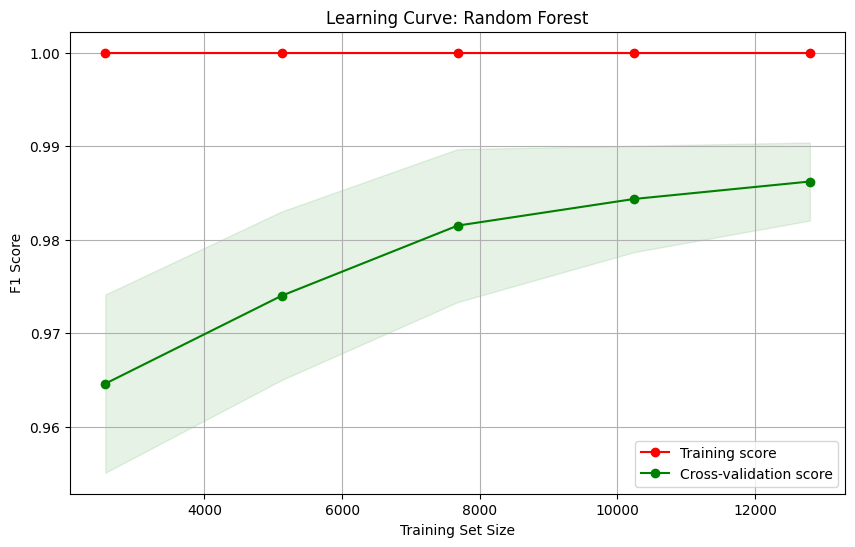

In [ ]:
plot_learning_curve(rf_pipe, X_train, y_train, "Random Forest")

In [ ]:
from xgboost import XGBClassifier
from scipy.stats import randint, uniform

#XGBoost pipeline
xgb_pipe = Pipeline(steps=[
    ('preprocess', preprocess_pipeline),
    ('xgb', XGBClassifier(eval_metric='logloss'))
])

#XGBoost grid
xgb_param_dist = {
    'xgb__n_estimators': randint(50, 200),
    'xgb__max_depth': randint(3, 10),
    'xgb__learning_rate': uniform(0.01, 0.3),
    'xgb__subsample': uniform(0.6, 0.4)
}

search_xgb = RandomizedSearchCV(xgb_pipe, xgb_param_dist, n_iter=20, n_jobs=1, cv=5, error_score='raise')
search_xgb.fit(X_train, y_train)
print("Best CV score = %0.3f:" % search_xgb.best_score_)
print("Best parameters: ", search_xgb.best_params_)

#store the best params and best model for later use
XGB_best_params = search_xgb.best_params_
XGB_best_model = search_xgb.best_estimator_

In [ ]:
results_xgb = evaluate_model(X_test, y_test, XGB_best_model, 'XGB Boost')

print(f"f1 score = {results_xgb['F1-Score']}" )
print(f"PR Auc = {results_xgb['PR-AUC']}")
print(f"Roc Auc = {results_xgb['ROC-AUC']} ")

f1 score = 0.991304347826087
PR Auc = 0.9992108633966583
Roc Auc = 0.9999114123092596 


<Figure size 3000x1800 with 0 Axes>

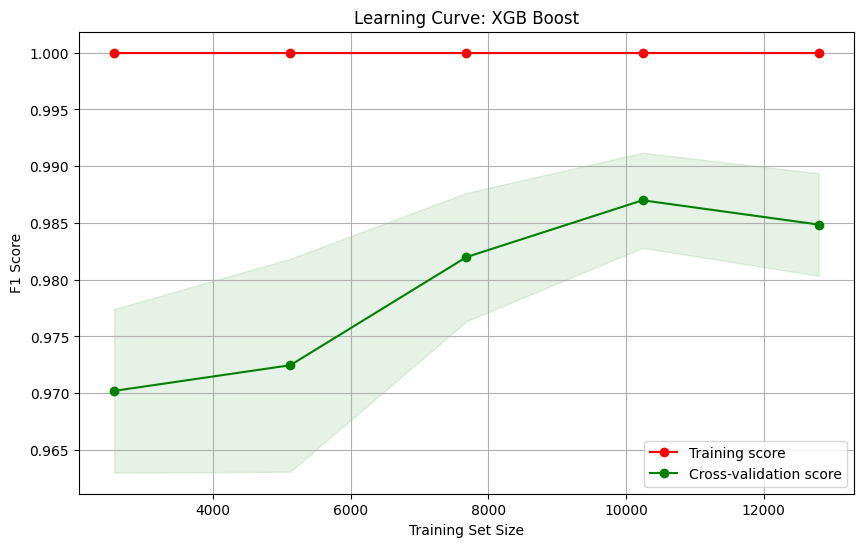

In [ ]:
plot_learning_curve(xgb_pipe, X_train, y_train, "XGB Boost")

In [ ]:
from lightgbm import LGBMClassifier

#LightGBM pipeline
lgbm_pipe = Pipeline(steps=[
    ('preprocess', preprocess_pipeline),
    ('lgbm', LGBMClassifier(verbose=-1))
])

#LightGBM grid
lgbm_param_dist = {
    'lgbm__n_estimators': randint(50, 200),
    'lgbm__max_depth': randint(3, 10),
    'lgbm__learning_rate': uniform(0.01, 0.3),
    'lgbm__num_leaves': randint(20, 50)
}

search_lgbm = RandomizedSearchCV(lgbm_pipe, lgbm_param_dist, n_iter=20, n_jobs=1, cv=5, error_score='raise')
search_lgbm.fit(X_train, y_train)

print("Best CV score = %0.3f:" % search_lgbm.best_score_)
print("Best parameters: ", search_lgbm.best_params_)

#store the best params and best model for later use
LGBM_best_params = search_lgbm.best_params_
LGBM_best_model = search_lgbm.best_estimator_

Best CV score = 0.998:
Best parameters:  {'lgbm__learning_rate': np.float64(0.2655145441421959), 'lgbm__max_depth': 8, 'lgbm__n_estimators': 105, 'lgbm__num_leaves': 48}


In [ ]:
results_lgbm = evaluate_model(X_test, y_test, LGBM_best_model, 'LGBM Boost')

print(f"f1 score = {results_lgbm['F1-Score']}" )
print(f"PR Auc = {results_lgbm['PR-AUC']}")
print(f"Roc Auc = {results_lgbm['ROC-AUC']} ")

f1 score = 0.992721979621543
PR Auc = 0.9996531150914586
Roc Auc = 0.999964406731399 


<Figure size 3000x1800 with 0 Axes>

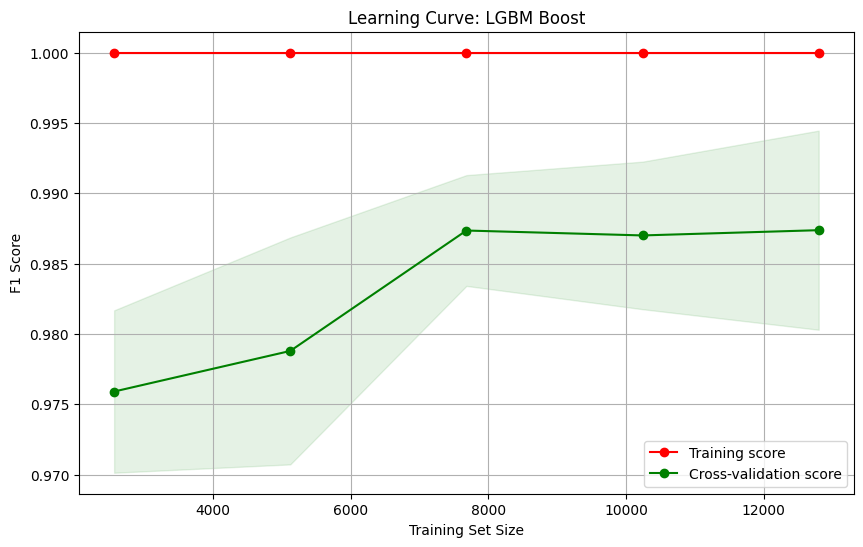

In [ ]:
plot_learning_curve(lgbm_pipe, X_train, y_train, "LGBM Boost")